# Volume Profile + CVD Strategy — v14 (Corrected Context + 5M Bars)

V14 focuses on fixing implementation validity before adding new rules:
- 5M execution bars (was 1M in v13)
- CandleBuffer cache bug fixed (get_60m_profile never computed)
- Migration slope order fixed (update_prev was before state calc)
- 5-state migration replaces 3-state
- VAL_REJECTION_LONG: only active setup; VAH_SHORT/VAH_RECLAIM: diagnostics-first
- Disk-based download cache, DayProfile prev_agg_cache (RAM reduction)
- 15-experiment matrix validating composite/migration/rejection sensitivity
- MFE/MAE tracking, 11 CSV exports


In [1]:
import io, zipfile, warnings, time, math, collections, tempfile, shutil
from collections import defaultdict, OrderedDict
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dataclasses import dataclass, field
from nautilus_trader.test_kit.providers import TestInstrumentProvider

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':120,'figure.figsize':(14,5)})
INSTRUMENT = TestInstrumentProvider.btcusdt_perp_binance()
TICK_SIZE, VA_PCT = 0.1, 0.70

PROFILE_DAYS = ['2024-03-04','2024-03-05','2024-03-06','2024-03-07','2024-03-08']
TEST_DAYS    = ['2024-03-11','2024-03-12','2024-03-13','2024-03-14','2024-03-15',
                '2024-03-16','2024-03-17','2024-03-18','2024-03-19','2024-03-20',
                '2024-03-21','2024-03-22','2024-03-23','2024-03-24','2024-03-25',
                '2024-03-26','2024-03-27','2024-03-28']

ACCOUNT_BALANCE  = 100_000.0
MAX_LEVERAGE     = 3.0
MAX_BTC_SIZE     = 5.0
TOUCH_BUFFER     = 0.002
CVD_LOOKBACK = 5
SESSION_CVD_LOOKBACK = 30
DAILY_HARD_LOSS    = 0.020

# 5M bars: 300_000 ms blocks
BAR_MS = 300_000

OUT_DIR = Path('outputs/v14')
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENTS = [
    {'id':'A',  'active_setups':['VAL_REJECTION_LONG','VAH_REJECTION_SHORT'],
     'profile_mode':'hybrid','target_model':'40_40_20','stop_model':'structure',
     'filter_set':'composite_migration','desc':'v13 baseline (fixed)'},
    {'id':'A0', 'active_setups':['VAL_REJECTION_LONG','VAH_REJECTION_SHORT'],
     'profile_mode':'hybrid','target_model':'40_40_20','stop_model':'structure',
     'filter_set':'composite_migration','desc':'Fixed migration + 5M bars'},
    {'id':'A1', 'active_setups':['VAL_REJECTION_LONG'],
     'profile_mode':'hybrid','target_model':'40_40_20','stop_model':'structure',
     'filter_set':'composite_migration','desc':'VAL_REJECTION only'},
    {'id':'B1', 'active_setups':['VAH_REJECTION_SHORT'],
     'profile_mode':'hybrid','target_model':'60_20_20','stop_model':'structure',
     'filter_set':'composite_migration','desc':'VAH_SHORT only strict'},
    {'id':'C1', 'active_setups':['VAL_REJECTION_LONG','VAH_REJECTION_SHORT'],
     'profile_mode':'hybrid','target_model':'40_40_20','stop_model':'structure',
     'filter_set':'composite_migration','desc':'VAL + strict VAH'},
    {'id':'D1', 'active_setups':['VAL_REJECTION_LONG'],
     'profile_mode':'hybrid','target_model':'40_40_20','stop_model':'structure',
     'filter_set':'none','desc':'No composite/migration'},
    {'id':'D2', 'active_setups':['VAL_REJECTION_LONG'],
     'profile_mode':'hybrid','target_model':'40_40_20','stop_model':'structure',
     'filter_set':'composite_only','desc':'Composite only'},
    {'id':'D3', 'active_setups':['VAL_REJECTION_LONG'],
     'profile_mode':'hybrid','target_model':'40_40_20','stop_model':'structure',
     'filter_set':'migration_only','desc':'Migration only'},
    {'id':'D4', 'active_setups':['VAL_REJECTION_LONG'],
     'profile_mode':'hybrid','target_model':'40_40_20','stop_model':'structure',
     'filter_set':'composite_migration','desc':'Composite + migration'},
    {'id':'D5', 'active_setups':['VAL_REJECTION_LONG'],
     'profile_mode':'hybrid','target_model':'40_40_20','stop_model':'structure',
     'filter_set':'strict_composite_migration','desc':'Strict composite+migration'},
    {'id':'E1', 'active_setups':['VAL_REJECTION_LONG'],
     'profile_mode':'hybrid','target_model':'40_40_20','stop_model':'structure',
     'filter_set':'composite_migration','close_loc_min':0.50,'desc':'Close loc >= 0.50'},
    {'id':'E2', 'active_setups':['VAL_REJECTION_LONG'],
     'profile_mode':'hybrid','target_model':'40_40_20','stop_model':'structure',
     'filter_set':'composite_migration','close_loc_min':0.55,'desc':'Close loc >= 0.55'},
    {'id':'E3', 'active_setups':['VAL_REJECTION_LONG'],
     'profile_mode':'hybrid','target_model':'40_40_20','stop_model':'structure',
     'filter_set':'composite_migration','close_loc_min':0.60,'desc':'Close loc >= 0.60'},
    {'id':'F1', 'active_setups':['VAL_REJECTION_LONG'],
     'profile_mode':'hybrid','target_model':'40_40_20','stop_model':'structure',
     'filter_set':'composite_migration','next_candle_entry':True,'desc':'Entry on next candle'},
]

print(f'Profile: {PROFILE_DAYS[0]}..{PROFILE_DAYS[-1]}  Test: {TEST_DAYS[0]}..{TEST_DAYS[-1]} ({len(TEST_DAYS)} days)')
print(f'Experiments: {len(EXPERIMENTS)} configs | 5M bars ({BAR_MS//60000}min)')

Profile: 2024-03-04..2024-03-08  Test: 2024-03-11..2024-03-28 (18 days)
Experiments: 14 configs | 5M bars (5min)


In [2]:
# === Download with Disk Cache ===
CACHE_DIR = Path(tempfile.mkdtemp(prefix='v14_cache_'))
CACHE_USED = {}  # track which keys were cached to disk

def dl(data_type, date, retries=3):
    k=(data_type,date)
    f=CACHE_DIR / f'{data_type}_{date}.zip'
    if f.exists():
        CACHE_USED[k]='disk'
        return f.read_bytes()
    url=f'https://data.binance.vision/data/futures/um/daily/{data_type}/BTCUSDT/BTCUSDT-{data_type}-{date}.zip'
    for attempt in range(retries):
        try:
            r=requests.get(url, timeout=120); r.raise_for_status()
            f.write_bytes(r.content)
            CACHE_USED[k]='fresh'
            return r.content
        except Exception as e:
            if attempt<retries-1:
                print(f'  Retry {attempt+1}/{retries} for {url}: {e}')
                time.sleep(3*(attempt+1))
            else:
                raise

def rd_agg(date):
    z=zipfile.ZipFile(io.BytesIO(dl('aggTrades',date)))
    c=[n for n in z.namelist() if n.endswith('.csv')][0]
    return pd.read_csv(z.open(c))

def rd_bk(date, sample=50):
    z=zipfile.ZipFile(io.BytesIO(dl('bookTicker',date)))
    c=[n for n in z.namelist() if n.endswith('.csv')][0]
    return pd.read_csv(z.open(c), skiprows=lambda i: i>0 and i%sample!=0)

print(f'Helper ready. Cache: {CACHE_DIR}')

Helper ready. Cache: C:\Users\cyt\AppData\Local\Temp\v14_cache_3fg9aub2


In [3]:
# === Profile Calculator ===
@dataclass
class DayProfile:
    date:str; poc:float; vah:float; val:float
    total_volume:float; price_levels:dict=field(repr=False)

def compute_vp(price_levels, total_volume):
    sp=sorted(price_levels.keys()); cp=max(price_levels,key=price_levels.get)
    pp=sp.index(cp); cv=price_levels[cp]; inc={cp}; l,r=pp-1,pp+1
    while cv<total_volume*VA_PCT and (l>=0 or r<len(sp)):
        vl=price_levels[sp[l]] if l>=0 else 0
        vr=price_levels[sp[r]] if r<len(sp) else 0
        if vl>=vr and l>=0: inc.add(sp[l]); cv+=vl; l-=1
        elif r<len(sp): inc.add(sp[r]); cv+=vr; r+=1
        else: break
    return DayProfile(date='',poc=cp,vah=max(inc),val=min(inc),total_volume=total_volume,price_levels=price_levels)

def calc_profile(df):
    df=df.copy(); df['b']=np.round(df['price']/TICK_SIZE)*TICK_SIZE
    vp=df.groupby('b')['quantity'].sum(); tv=vp.sum(); poc=vp.idxmax()
    levels=vp.sort_index(); idx=list(levels.index); pp=idx.index(poc)
    cv=levels.iloc[pp]; inc={poc}; t=tv*VA_PCT; l,r=pp-1,pp+1
    while cv<t and (l>=0 or r<len(idx)):
        vl=levels.iloc[l] if l>=0 else 0
        vr=levels.iloc[r] if r<len(idx) else 0
        if vl>=vr and l>=0: inc.add(idx[l]); cv+=vl; l-=1
        elif r<len(idx): inc.add(idx[r]); cv+=vr; r+=1
        else: break
    ds=pd.Timestamp(df['transact_time'].iloc[0],unit='ms').strftime('%Y-%m-%d')
    return DayProfile(date=ds,poc=poc,vah=max(inc),val=min(inc),total_volume=tv,price_levels=vp.to_dict())

In [4]:
# === Data Structures (5M Bars) ===
@dataclass
class FiveMinuteCandle:
    open_p:float; high:float; low:float; close:float
    buy_vol:float; sell_vol:float; total_vol:float
    delta:float; delta_pct:float
    ts_start:int; ts_end:int
    imb_avg:float=0.0
    volume_by_price:dict=None
    max_price_level_share:float=0.0
    close_location:float=0.0
    body_ratio:float=0.0
    
    def finalize(self):
        rng=self.high-self.low
        self.close_location=(self.close-self.low)/rng if rng>0 else 0.5
        body=abs(self.close-self.open_p)
        self.body_ratio=body/rng if rng>0 else 0
        if self.volume_by_price:
            mx=max(self.volume_by_price.values()) if self.volume_by_price else 0
            self.max_price_level_share=mx/self.total_vol if self.total_vol>0 else 0

class BarBuilder:
    def __init__(self):
        self.bars=[]
        self._cur=None; self._vp={}; self._ts=0
        self._imb_buf=[]
    
    def on_trade(self,price,qty,is_buyer_maker,ts):
        if self._cur is None:
            self._cur={'open':price,'high':price,'low':price,'close':price,
                       'buy':0,'sell':0,'ts':ts}
        self._cur['high']=max(self._cur['high'],price)
        self._cur['low']=min(self._cur['low'],price)
        self._cur['close']=price
        if not is_buyer_maker: self._cur['buy']+=qty
        else: self._cur['sell']+=qty
        b=round(price/TICK_SIZE)*TICK_SIZE
        self._vp[b]=self._vp.get(b,0)+qty
        self._ts=ts
    
    def on_quote(self,bp,ap,bq,aq):
        imb=(bq/aq)*100 if aq>0 and bq>0 else 0
        self._imb_buf.append(imb)
        if len(self._imb_buf)>100: self._imb_buf.pop(0)
    
    def on_minute(self,ts):
        if self._cur is None: return
        c=self._cur
        delta=c['buy']-c['sell']; total=c['buy']+c['sell']
        dr=delta/total if total>0 else 0
        imb_avg=sum(self._imb_buf)/len(self._imb_buf) if self._imb_buf else 0
        candle=FiveMinuteCandle(
            open_p=c['open'],high=c['high'],low=c['low'],close=c['close'],
            buy_vol=c['buy'],sell_vol=c['sell'],total_vol=total,
            delta=delta,delta_pct=dr,
            ts_start=c['ts'],ts_end=ts,
            imb_avg=imb_avg,
            volume_by_price=dict(self._vp))
        candle.finalize()
        self.bars.append(candle)
        self._cur=None; self._vp={}
    
    def finalize(self):
        self.on_minute(self._ts)

def build_bars(trades_df, quotes_df):
    bb=BarBuilder()
    events=[]
    for _,r in quotes_df.iterrows():
        events.append({'ts':int(r['transaction_time']),'t':'q',
            'bp':float(r['best_bid_price']),'bq':float(r['best_bid_qty']),
            'ap':float(r['best_ask_price']),'aq':float(r['best_ask_qty'])})
    for _,r in trades_df.iterrows():
        events.append({'ts':int(r['transact_time']),'t':'tr',
            'p':float(r['price']),'q':float(r['quantity']),
            'b':bool(r['is_buyer_maker'])})
    events.sort(key=lambda x:x['ts'])
    last_block=-1
    for ev in events:
        m=ev['ts']//BAR_MS
        if m!=last_block and last_block!=-1:
            bb.on_minute(ev['ts'])
        last_block=m
        if ev['t']=='q': bb.on_quote(ev['bp'],ev['ap'],ev['bq'],ev['aq'])
        else: bb.on_trade(ev['p'],ev['q'],ev['b'],ev['ts'])
    bb.finalize()
    return bb.bars

In [5]:
# === Composite Bias Engine ===
class CompositeBiasScorer:
    def __init__(self, comp_val, comp_poc, comp_vah):
        self.comp_val=comp_val; self.comp_poc=comp_poc; self.comp_vah=comp_vah
        self.comp_mid=(comp_val+comp_vah)/2
    
    def score(self, current_price, active_poc, active_mid, dyn_60m_poc_slope, dyn_180m_poc_slope, session_cvd):
        s=0
        if current_price>self.comp_poc: s+=1
        else: s-=1
        if active_poc>self.comp_poc: s+=1
        elif active_poc<self.comp_poc: s-=1
        if active_mid>self.comp_mid: s+=1
        elif active_mid<self.comp_mid: s-=1
        if dyn_60m_poc_slope>0: s+=1
        elif dyn_60m_poc_slope<0: s-=1
        if dyn_180m_poc_slope>0: s+=1
        elif dyn_180m_poc_slope<0: s-=1
        if session_cvd=='bullish': s+=1
        elif session_cvd=='bearish': s-=1
        return s
    
    def classify(self, score):
        if score>=3: return 'BULLISH'
        if score>=1: return 'NEUTRAL_BULLISH'
        if score<=-3: return 'BEARISH'
        if score<=-1: return 'NEUTRAL_BEARISH'
        return 'NEUTRAL'

class CandleBuffer:
    def __init__(self):
        self.candles=[]
        self._60m_cache=None; self._180m_cache=None
    
    def push(self, c):
        self.candles.append(c)
        self._60m_cache=None; self._180m_cache=None
    
    def _merge_vp(self, n):
        vp={}
        for c in self.candles[-n:]:
            if c.volume_by_price:
                for px,q in c.volume_by_price.items():
                    vp[px]=vp.get(px,0)+q
        return vp, sum(c.total_vol for c in self.candles[-n:])
    
    def get_60m_profile(self):
        if self._60m_cache is not None:
            return self._60m_cache
        if len(self.candles) < 60:
            return None
        vp,tv=self._merge_vp(60)
        if len(vp)==0: return None
        self._60m_cache=compute_vp(vp,tv)
        return self._60m_cache
    
    def get_180m_profile(self):
        if self._180m_cache is not None:
            return self._180m_cache
        if len(self.candles) < 180:
            return None
        vp,tv=self._merge_vp(180)
        if len(vp)==0: return None
        self._180m_cache=compute_vp(vp,tv)
        return self._180m_cache
    
    def clear_old(self):
        while len(self.candles)>180: self.candles.pop(0)

class MigrationDetector:
    def __init__(self, poc_slope_min=0.001):
        self.poc_slope_min=poc_slope_min
        self._prev_60m=None  # DayProfile
        self._prev_180m=None  # DayProfile
    
    def update_prev(self, p60, p180):
        if p60: self._prev_60m=p60
        if p180: self._prev_180m=p180
    
    def _overlap_ratio(self, cur, prev):
        if cur is None or prev is None: return 1.0
        cur_w=cur.vah-cur.val
        if cur_w<=0: return 1.0
        overlap=max(0, min(cur.vah, prev.vah)-max(cur.val, prev.val))
        return overlap/cur_w
    
    def _price_accepted(self, bar_closes, active_poc, above=True, n=3, lookback=5):
        if bar_closes is None or len(bar_closes)<lookback: return True
        recent=bar_closes[-lookback:]
        if above: cnt=sum(1 for c in recent if c>active_poc)
        else: cnt=sum(1 for c in recent if c<active_poc)
        return cnt>=n
    
    def migration_state(self, p60, p180, price, active_poc, bar_closes=None):
        th=self.poc_slope_min
        s60p=s60m=s180p=s180m=0
        s60_va_overlap=1.0; s180_va_overlap=1.0
        
        if p60 and self._prev_60m:
            s60p=p60.poc-self._prev_60m.poc
            s60m=((p60.vah+p60.val)/2)-((self._prev_60m.vah+self._prev_60m.val)/2)
            s60_va_overlap=self._overlap_ratio(p60, self._prev_60m)
        
        if p180 and self._prev_180m:
            s180p=p180.poc-self._prev_180m.poc
            s180m=((p180.vah+p180.val)/2)-((self._prev_180m.vah+self._prev_180m.val)/2)
            s180_va_overlap=self._overlap_ratio(p180, self._prev_180m)
        
        price_above=self._price_accepted(bar_closes, active_poc, above=True)
        price_below=self._price_accepted(bar_closes, active_poc, above=False)
        
        bullish_60=(s60p>th or s60m>th)
        bearish_60=(s60p<-th or s60m<-th)
        
        # 5-state classification using 60M profile as primary
        if p60 and self._prev_60m and s60_va_overlap<0.60:
            if bullish_60 and s180p>=0 and price_above:
                return 'STRONG_BULLISH', s60p, s60m, s180p
            if bearish_60 and s180p<=0 and price_below:
                return 'STRONG_BEARISH', s60p, s60m, s180p
        
        if p60 and self._prev_60m and s60_va_overlap>=0.60:
            if (s60p>th or s60m>th) and s180p>=-th and not price_below:
                return 'MODERATE_BULLISH', s60p, s60m, s180p
            if (s60p<-th or s60m<-th) and s180p<=th and not price_above:
                return 'MODERATE_BEARISH', s60p, s60m, s180p
        
        if p60 and self._prev_60m and s60_va_overlap>=0.70 and abs(s60p)<th and abs(s60m)<th:
            return 'NEUTRAL_OVERLAP', s60p, s60m, s180p
        
        return 'NO_CLEAR', s60p, s60m, s180p

class OrderflowConfirmer:
    @staticmethod
    def cvd_failed_recovery(cvd_hist, n=5, back=15):
        if len(cvd_hist)<back+n: return False, False
        recent=cvd_hist[-back:]
        bullish=(min(recent)>min(cvd_hist[-(back+n):-back]) and cvd_hist[-1]>cvd_hist[-n])
        bearish=(max(recent)<max(cvd_hist[-(back+n):-back]) and cvd_hist[-1]<cvd_hist[-n])
        return bullish, bearish
    
    @staticmethod
    def delta_ok(delta_pcts, bullish=True, n=3):
        if len(delta_pcts)==0: return False
        cur=delta_pcts[-1]
        avg=sum(delta_pcts[-n:])/n if len(delta_pcts)>=n else cur
        if bullish: return cur>=0.0010 or avg>=0.0005
        return cur<=-0.0010 or avg<=-0.0005
    
    @staticmethod
    def imbalance_ok(imb_buf, buy=True, n=3, threshold=1.2):
        vals=[imb_buf[-i] for i in range(1,min(n+1,len(imb_buf)+1)) if len(imb_buf)>=i]
        if not vals: return False
        return sum(vals)/len(vals)>=threshold
    
    @staticmethod
    def absorption_reversal(prices, cvd_hist, lookback=5):
        if len(prices)<lookback+1 or len(cvd_hist)<lookback+1: return False, False
        bullish=(prices[-1]>max(prices[-(lookback+1):-1]) and cvd_hist[-1]<=max(cvd_hist[-(lookback+1):-1]))
        bearish=(prices[-1]<min(prices[-(lookback+1):-1]) and cvd_hist[-1]>=min(cvd_hist[-(lookback+1):-1]))
        return bullish, bearish
    
    @staticmethod
    def volume_ok(volumes, mult=1.0):
        if len(volumes)<20: return False
        return volumes[-1]>=np.median(volumes[-20:])*mult

class StructureStopCalc:
    @staticmethod
    def long_stop(entry, active_val, rejection_low, atr):
        stop_buffer=max(entry*0.0005, atr*0.25)
        structure_stop=min(rejection_low, active_val)-stop_buffer
        min_dist=max(entry*0.0055, atr*0.40)
        max_dist=max(entry*0.0070, atr*1.30)
        dist=entry-structure_stop
        if dist<min_dist: structure_stop=entry-min_dist; dist=min_dist
        return structure_stop, dist, dist>max_dist
    
    @staticmethod
    def short_stop(entry, active_vah, rejection_high, atr):
        stop_buffer=max(entry*0.0005, atr*0.25)
        structure_stop=max(rejection_high, active_vah)+stop_buffer
        min_dist=max(entry*0.0060, atr*0.40)
        max_dist=max(entry*0.0085, atr*1.70)
        dist=structure_stop-entry
        if dist<min_dist: structure_stop=entry+min_dist; dist=min_dist
        return structure_stop, dist, dist>max_dist

class RiskManager:
    def __init__(self, base_risk=0.0075):
        self.base_risk=base_risk
    
    def context_multiplier(self, setup, composite_state, migration_state):
        if setup=='VAL_REJECTION_LONG':
            if composite_state in ('BULLISH','NEUTRAL_BULLISH'): return 1.0
            if composite_state=='NEUTRAL': return 0.75
            if composite_state=='NEUTRAL_BEARISH':
                if migration_state in ('STRONG_BEARISH','MODERATE_BEARISH','NO_CLEAR'): return 0.0
                return 0.50
            return 0.0
        elif setup=='VAH_REJECTION_SHORT':
            if composite_state in ('BEARISH','NEUTRAL_BEARISH'): return 1.0
            if composite_state=='NEUTRAL': return 0.75
            if composite_state=='NEUTRAL_BULLISH':
                if migration_state in ('STRONG_BULLISH','MODERATE_BULLISH','NO_CLEAR'): return 0.0
                return 0.50
            return 0.0
        return 0.0
    
    def size_position(self, entry, stop, setup, composite_state, migration_state):
        mult=self.context_multiplier(setup, composite_state, migration_state)
        if mult<=0: return 0.0, 0.0, mult
        risk_usdt=ACCOUNT_BALANCE*self.base_risk*mult
        sd=abs(entry-stop)
        if sd<=0: return 0.0, 0.0, mult
        raw=risk_usdt/sd
        max_not=ACCOUNT_BALANCE*MAX_LEVERAGE/entry
        final=min(raw,max_not,MAX_BTC_SIZE)
        if final*sd<0.25*risk_usdt or final<0.001: return 0.0, 0.0, mult
        return final, final*entry/ACCOUNT_BALANCE, mult

class DiagnosticsCollector:
    def __init__(self):
        self.trade_log=[]
        self.funnel=defaultdict(lambda:defaultdict(int))
        self.fail_funnel=defaultdict(lambda:defaultdict(int))
        self.vah_reclaim_diag=[]
        self.vah_short_candidates=[]
        self.profile_avail={'60m':{'eligible':0,'available':0},'180m':{'eligible':0,'available':0}}
        self.migration_states=defaultdict(int)
        self.composite_bias_states=defaultdict(int)
        self.context_pnl=defaultdict(lambda:{'trades':0,'pnl':0.0})
    
    def log_funnel(self, setup, stage, passed=True):
        if passed: self.funnel[setup][stage]+=1
        else: self.fail_funnel[setup][stage]+=1
    
    def log_trade(self, **kw): self.trade_log.append(kw)
    
    def log_vah_short_candidate(self, **kw): self.vah_short_candidates.append(kw)

In [6]:
# === Strategy V14 ===
class StrategyV14:
    def __init__(self, prior_val, prior_vah, prior_poc, prior_date, prev_agg_prof=None,
                 current_date=None, exp_config=None, comp_scorer=None):
        self.prior_val=prior_val; self.prior_vah=prior_vah; self.prior_poc=prior_poc
        self.prior_date=prior_date; self.prev_agg_prof=prev_agg_prof
        self.active_VAL=prior_val; self.active_VAH=prior_vah; self.active_POC=prior_poc
        self.current_date=current_date
        cfg=exp_config or {}
        self.pm=cfg.get('profile_mode','hybrid')
        self.tm=cfg.get('target_model','40_40_20')
        self.sm=cfg.get('stop_model','structure')
        self.fs=cfg.get('filter_set','composite_migration')
        self.active_setups=cfg.get('active_setups',['VAL_REJECTION_LONG'])
        self.close_loc_min=cfg.get('close_loc_min',0.55)
        self.next_candle_entry=cfg.get('next_candle_entry',False)
        self.composite_scorer=comp_scorer
        
        self.day_open=None; self.bar_index=0; self.bar_ts=0
        self.bar_lows=[]; self.bar_highs=[]; self.bar_closes=[]; self.bar_deltas=[]
        self.cvd=0.0; self.cvd_history=[]; self.imb_buf=[]; self.volumes_20=[]
        self.bar_ranges=[]; self.atr=0.0; self.atr_ready=False
        self.active_source='prior_daily'; self.profile_checked=False
        
        self.trade=None; self.daily_pnl=0.0; self.consecutive_loss_dir={}
        self.last_stop_bar=0; self.last_stop_dir=None
        self.setup=defaultdict(lambda:{'enabled':True,'entries':0,'failures':0})
        self.setup['VAH_RECLAIM_LONG']['enabled']=False
        if 'VAH_REJECTION_SHORT' not in self.active_setups:
            self.setup['VAH_REJECTION_SHORT']['enabled']=False
        
        self.cbuf=CandleBuffer()
        self.migration_detector=MigrationDetector(poc_slope_min=0.001)
        self.orderflow=OrderflowConfirmer()
        self.structure_stop=StructureStopCalc()
        self.risk_mgr=RiskManager(base_risk=0.0075)
        self.diag=DiagnosticsCollector()
        
        self.composite_bias_state='NEUTRAL'
        self.migration_state='NO_CLEAR'
        self.dyn_60m_poc_slope=0; self.dyn_180m_poc_slope=0
        
        # MFE/MAE tracking
        self._entry_price=0; self._mfe=0; self._mae=0; self._mfe_mae_active=False
        self._prev_entry_ts=0
    
    def feed_bar(self, candle):
        ts=candle.ts_start
        self.bar_ts=ts
        
        self.cvd+=candle.delta
        self.cvd_history.append(self.cvd)
        self.bar_deltas.append(candle.delta)
        self.bar_lows.append(candle.low)
        self.bar_highs.append(candle.high)
        self.bar_closes.append(candle.close)
        self.volumes_20.append(candle.total_vol)
        self.imb_buf.append(candle.imb_avg)
        
        max_hist=max(CVD_LOOKBACK*2,SESSION_CVD_LOOKBACK*2,30)
        if len(self.bar_lows)>max_hist:
            self.bar_lows.pop(0); self.bar_highs.pop(0); self.bar_closes.pop(0)
            self.cvd_history.pop(0); self.bar_deltas.pop(0)
        if len(self.volumes_20)>20: self.volumes_20.pop(0)
        if len(self.imb_buf)>100: self.imb_buf.pop(0)
        
        rng=candle.high-candle.low
        self.bar_ranges.append(rng)
        if len(self.bar_ranges)>14: self.bar_ranges.pop(0)
        if len(self.bar_ranges)>=14:
            self.atr=sum(self.bar_ranges)/len(self.bar_ranges)
            self.atr_ready=True
        
        self.cbuf.push(candle)
        if len(self.cbuf.candles)>180: self.cbuf.clear_old()
        
        # MFE/MAE tracking while in trade
        if self._mfe_mae_active and self.trade is not None:
            if self.trade['side']=='LONG':
                self._mfe=max(self._mfe, candle.high-self._entry_price)
                self._mae=min(self._mae, candle.low-self._entry_price)
            else:
                self._mfe=max(self._mfe, self._entry_price-candle.low)
                self._mae=min(self._mae, self._entry_price-candle.high)
        
        self.bar_index+=1
    
    def _select_active_profile(self):
        if self.profile_checked: return
        self.profile_checked=True
        if self.day_open is None:
            self.day_open=self.bar_closes[0] if self.bar_closes else 0
        
        prev=pd.Timestamp(self.prior_date) if isinstance(self.prior_date,str) else pd.Timestamp(str(self.prior_date))
        cur=pd.Timestamp(self.current_date) if isinstance(self.current_date,str) else pd.Timestamp(str(self.current_date))
        weekend=(cur-prev).days>1
        
        open_gap_pct=abs(self.day_open-self.prior_poc)/self.prior_poc if self.prior_poc>0 else 0
        open_gap_atr=open_gap_pct/(self.atr/self.prior_poc) if self.atr>0 and self.prior_poc>0 else 99
        
        stale=False
        if self.pm=='always_24h': stale=True
        elif self.pm=='always_prior': stale=False
        elif self.pm=='hybrid_wide':
            if open_gap_pct>0.010: stale=True
            if open_gap_atr>1.5: stale=True
            if weekend and open_gap_pct>0.010: stale=True
        else:
            if open_gap_pct>0.004: stale=True
            if open_gap_atr>1.0: stale=True
            if weekend and open_gap_pct>0.005: stale=True
        
        if not stale:
            self.active_VAL=self.prior_val; self.active_VAH=self.prior_vah; self.active_POC=self.prior_poc
            self.active_source='prior_daily'; return
        
        if self.prev_agg_prof is not None:
            self.active_VAL=self.prev_agg_prof.val
            self.active_VAH=self.prev_agg_prof.vah
            self.active_POC=self.prev_agg_prof.poc
            self.active_source='rolling_24h'
    
    def _rejection_ok(self, side, candle):
        if side=='LONG':
            if not (candle.low<=self.active_VAL*(1+TOUCH_BUFFER)): return False
            if candle.close_location<self.close_loc_min: return False
            if candle.close<self.active_VAL: return False
            if candle.close<candle.open_p:  # red candle
                if candle.close_location>=0.40: return False
                delta_ok=self.orderflow.delta_ok(self.bar_deltas,bullish=True)
                cvd_rec,_=self.orderflow.cvd_failed_recovery(self.cvd_history)
                if not (delta_ok or cvd_rec): return False
            return True
        else:
            close_loc_max=1.0-self.close_loc_min
            if not (candle.high>=self.active_VAH*(1-TOUCH_BUFFER)): return False
            if candle.close_location>close_loc_max: return False
            if candle.close>self.active_VAH: return False
            return True
    
    def _update_composite_migration(self):
        p60=self.cbuf.get_60m_profile()
        p180=self.cbuf.get_180m_profile()
        
        # Track profile availability
        if len(self.cbuf.candles)>=60:
            self.diag.profile_avail['60m']['eligible']+=1
            if p60 is not None: self.diag.profile_avail['60m']['available']+=1
        if len(self.cbuf.candles)>=180:
            self.diag.profile_avail['180m']['eligible']+=1
            if p180 is not None: self.diag.profile_avail['180m']['available']+=1
        
        # Fixed order: compute state first, then update prev
        ms, s60p, s60m, s180p=self.migration_detector.migration_state(
            p60, p180, self.bar_closes[-1] if self.bar_closes else 0,
            self.active_POC, self.bar_closes)
        self.migration_state=ms
        self.dyn_60m_poc_slope=s60p; self.dyn_180m_poc_slope=s180p
        
        self.migration_detector.update_prev(p60, p180)
        self.diag.migration_states[ms]+=1
        
        if self.composite_scorer and self.bar_closes:
            session_cvd='bullish' if (len(self.cvd_history)>=SESSION_CVD_LOOKBACK and 
                self.cvd_history[-1]>self.cvd_history[-SESSION_CVD_LOOKBACK]) else 'bearish'
            scr=self.composite_scorer.score(
                self.bar_closes[-1], self.active_POC, (self.active_VAL+self.active_VAH)/2,
                s60p, s180p, session_cvd)
            self.composite_bias_state=self.composite_scorer.classify(scr)
            self.diag.composite_bias_states[self.composite_bias_state]+=1
    
    def _check_val_rejection_long(self, candle):
        s='VAL_REJECTION_LONG'
        self.diag.log_funnel(s,'near_level',True)
        if not self.setup[s]['enabled'] or self.setup[s]['entries']>=1:
            return self.diag.log_funnel(s,'setup_disabled',False)
        self.diag.log_funnel(s,'setup_enabled',True)
        
        if self.active_source=='stale_no_fallback': return self.diag.log_funnel(s,'profile_invalid',False)
        self.diag.log_funnel(s,'profile_valid',True)
        
        # Composite bias gating
        composite_active=self.fs in ('composite_migration','composite_only','strict_composite_migration')
        if composite_active:
            if self.composite_bias_state=='BEARISH':
                return self.diag.log_funnel(s,'composite_bias_rejected',False)
            if self.composite_bias_state=='NEUTRAL_BEARISH':
                if self.migration_state in ('STRONG_BEARISH','MODERATE_BEARISH','NO_CLEAR'):
                    return self.diag.log_funnel(s,'composite_bias_rejected',False)
        self.diag.log_funnel(s,'composite_bias_ok',True)
        
        # Migration gating
        migration_active=self.fs in ('composite_migration','migration_only','strict_composite_migration')
        if migration_active:
            if self.migration_state=='STRONG_BEARISH':
                return self.diag.log_funnel(s,'value_migration_rejected',False)
        self.diag.log_funnel(s,'value_migration_ok',True)
        
        if not self._rejection_ok('LONG', candle): return self.diag.log_funnel(s,'rejection_candle_invalid',False)
        self.diag.log_funnel(s,'rejection_candle_ok',True)
        
        # Orderflow: need >=3 of 5
        of1= self.bar_deltas[-1]>=0.0 if self.bar_deltas else False  # delta >= 0
        of2= sum(self.bar_deltas[-3:])/3>=0.0 if len(self.bar_deltas)>=3 else False  # avg 3 delta >= 0
        of3= self.cvd_history[-1]>self.cvd_history[-min(6,len(self.cvd_history))] if len(self.cvd_history)>=6 else False  # CVD > 5 bars ago
        _, rev_bearish=self.orderflow.absorption_reversal(self.bar_lows,self.cvd_history)
        of4= (not rev_bearish)  # no bearish absorption at lows
        of5= self.orderflow.volume_ok(self.volumes_20) if len(self.volumes_20)>=20 else False
        
        if sum([of1, of2, of3, of4, of5])<3:
            return self.diag.log_funnel(s,'orderflow_not_confirmed',False)
        self.diag.log_funnel(s,'orderflow_confirmed',True)
        
        if self.sm=='structure':
            rejection_low=min(self.bar_lows[-5:]) if len(self.bar_lows)>=5 else candle.low
            stop_px, sdist, too_wide=self.structure_stop.long_stop(
                candle.close, self.active_VAL, rejection_low, self.atr)
            if too_wide: return self.diag.log_funnel(s,'stop_too_wide',False)
        else:
            buffer=max(candle.close*0.0015,self.atr*0.5)
            swing=min(self.bar_lows[-5:]) if len(self.bar_lows)>=5 else candle.low
            stop_px=min(self.active_VAL-buffer,swing-buffer*0.5)
            if stop_px>=candle.close: return self.diag.log_funnel(s,'stop_invalid',False)
        self.diag.log_funnel(s,'stop_valid',True)
        
        r=candle.close-stop_px
        t1=self.active_POC; t1_dist=abs(t1-candle.close)
        if t1_dist<r*0.8: return self.diag.log_funnel(s,'target_too_close',False)
        t2=self.active_VAH; t2_dist=abs(t2-candle.close)
        if self.tm=='poc_only':
            pass
        elif self.tm=='50_50':
            if t1_dist<r*0.6: return self.diag.log_funnel(s,'target_too_close',False)
        elif self.tm=='60_20_20':
            if t1_dist<r*0.8: return self.diag.log_funnel(s,'target_too_close',False)
        else:
            if t2_dist<r*1.5 and t2_dist>0: return self.diag.log_funnel(s,'t2_target_too_close',False)
        self.diag.log_funnel(s,'target_valid',True)
        
        # Determine risk mult (NEUTRAL_BEARISH forced override if composite_active)
        forced_mult=None
        if composite_active and self.composite_bias_state=='NEUTRAL_BEARISH':
            forced_mult=0.50
        
        size, lev, mult=self.risk_mgr.size_position(
            candle.close, stop_px, s, self.composite_bias_state, self.migration_state)
        if forced_mult is not None:
            mult=forced_mult
            if mult<=0: return self.diag.log_funnel(s,'size_too_small',False)
            risk_usdt=ACCOUNT_BALANCE*0.0075*mult
            sd=abs(candle.close-stop_px)
            if sd>0:
                raw=risk_usdt/sd
                max_not=ACCOUNT_BALANCE*MAX_LEVERAGE/candle.close
                size=min(raw,max_not,MAX_BTC_SIZE)
                if size*sd<0.25*risk_usdt or size<0.001: return self.diag.log_funnel(s,'size_too_small',False)
                lev=size*candle.close/ACCOUNT_BALANCE
        
        if size<=0: return self.diag.log_funnel(s,'size_too_small',False)
        self.diag.log_funnel(s,'entered',True)
        
        # Track MFE/MAE
        self._entry_price=candle.close
        self._mfe=0; self._mae=0; self._mfe_mae_active=True
        
        self._enter(candle.close, s, 'LONG', stop_px, size, r, t1, t2, mult, candle.ts_start)
        return True
    
    def _check_vah_rejection_short(self, candle):
        s='VAH_REJECTION_SHORT'
        self.diag.log_funnel(s,'near_level',True)
        if not self.setup[s]['enabled'] or self.setup[s]['entries']>=1:
            return self.diag.log_funnel(s,'setup_disabled',False)
        self.diag.log_funnel(s,'setup_enabled',True)
        
        if self.active_source=='stale_no_fallback': return self.diag.log_funnel(s,'profile_invalid',False)
        self.diag.log_funnel(s,'profile_valid',True)
        
        composite_active=self.fs in ('composite_migration','composite_only','strict_composite_migration')
        if composite_active:
            if self.composite_bias_state=='BULLISH':
                return self.diag.log_funnel(s,'composite_bias_rejected',False)
        self.diag.log_funnel(s,'composite_bias_ok',True)
        
        migration_active=self.fs in ('composite_migration','migration_only','strict_composite_migration')
        if migration_active:
            if self.migration_state=='STRONG_BULLISH':
                return self.diag.log_funnel(s,'value_migration_rejected',False)
        self.diag.log_funnel(s,'value_migration_ok',True)
        
        if not self._rejection_ok('SHORT', candle): return self.diag.log_funnel(s,'rejection_candle_invalid',False)
        self.diag.log_funnel(s,'rejection_candle_ok',True)
        
        delta_ok=self.orderflow.delta_ok(self.bar_deltas,bullish=False)
        imb_ok=self.orderflow.imbalance_ok(self.imb_buf,buy=False)
        rev_bullish, _=self.orderflow.absorption_reversal(self.bar_highs,self.cvd_history)
        vol_ok=self.orderflow.volume_ok(self.volumes_20)
        _, cvd_rec_fail=self.orderflow.cvd_failed_recovery(self.cvd_history)
        
        if sum([delta_ok, imb_ok, vol_ok, (not rev_bullish), cvd_rec_fail])<3:
            return self.diag.log_funnel(s,'orderflow_not_confirmed',False)
        self.diag.log_funnel(s,'orderflow_confirmed',True)
        
        if self.sm=='structure':
            rejection_high=max(self.bar_highs[-5:]) if len(self.bar_highs)>=5 else candle.high
            stop_px, sdist, too_wide=self.structure_stop.short_stop(
                candle.close, self.active_VAH, rejection_high, self.atr)
            if too_wide: return self.diag.log_funnel(s,'stop_too_wide',False)
        else:
            buffer=max(candle.close*0.0015,self.atr*0.5)
            swing=max(self.bar_highs[-5:]) if len(self.bar_highs)>=5 else candle.high
            stop_px=max(self.active_VAH+buffer,swing+buffer*0.5)
            if stop_px<=candle.close: return self.diag.log_funnel(s,'stop_invalid',False)
        self.diag.log_funnel(s,'stop_valid',True)
        
        r=stop_px-candle.close
        t1=self.active_POC; t1_dist=abs(candle.close-t1)
        if t1_dist<r*0.8: return self.diag.log_funnel(s,'target_too_close',False)
        t2=self.active_VAL; t2_dist=abs(candle.close-t2)
        if self.tm=='poc_only':
            pass
        else:
            if t2_dist<r*1.5 and t2_dist>0: return self.diag.log_funnel(s,'t2_target_too_close',False)
        self.diag.log_funnel(s,'target_valid',True)
        
        size, lev, mult=self.risk_mgr.size_position(
            candle.close, stop_px, s, self.composite_bias_state, self.migration_state)
        if size<=0: return self.diag.log_funnel(s,'size_too_small',False)
        self.diag.log_funnel(s,'entered',True)
        
        self._entry_price=candle.close
        self._mfe=0; self._mae=0; self._mfe_mae_active=True
        
        if 'VAH_REJECTION_SHORT' in self.active_setups:
            self._enter(candle.close, s, 'SHORT', stop_px, size, r, t1, t2, mult, candle.ts_start)
        else:
            # Diagnostics-only: log candidate but don't enter
            self.diag.log_vah_short_candidate(
                date=self.current_date, ts=candle.ts_start, entry=candle.close,
                stop=stop_px, r=r, t1=t1, t2=t2, size=size, lev=lev, mult=mult,
                composite_bias=self.composite_bias_state,
                migration=self.migration_state,
                close_loc=candle.close_location,
                delta_pct=candle.delta_pct)
        return True
    
    def _check_vah_reclaim_long_diag(self, candle):
        if not candle: return
        self.diag.vah_reclaim_diag.append({
            'bar':self.bar_index,'price':candle.close,
            'above_vah':candle.close>self.active_VAH if self.active_VAH else False,
            'composite_bias':self.composite_bias_state,
            'migration':self.migration_state,
            'volume':candle.total_vol,
            'delta_pct':candle.delta_pct,
            'close_location':candle.close_location,
            'vol_vs_med':candle.total_vol/np.median(self.volumes_20[-20:]) if len(self.volumes_20)>=20 and np.median(self.volumes_20[-20:])>0 else 0
        })
    
    def _enter(self,price,setup,side,stop,size,r,t1,t2,mult,ts):
        self.trade={
            'side':side,'entry_px':price,'entry_ts':ts,
            'stop_px':stop,'total_size':size,'remaining_size':size,
            'setup':setup,'r_val':r,'t1':t1,'t2':t2,
            'target_1_hit':False,'target_2_hit':False,
            'trail_extreme':price,'failure_bars':0,
            'profile_source':self.active_source,'risk_mult':mult
        }
        self.setup[setup]['entries']+=1
        lev=size*price/ACCOUNT_BALANCE
        print(f'>>> {side} {price:.1f} stop={stop:.1f} sz={size:.3f} R={r:.1f} lev={lev:.1f}x ({setup}) src={self.active_source}')
    
    def _check_exit(self, close, candle):
        t=self.trade
        if t is None: return
        if (t['side']=='LONG' and close<=t['stop_px']) or (t['side']=='SHORT' and close>=t['stop_px']):
            self._close(close,'stop',t['remaining_size'],candle)
            self.last_stop_bar=self.bar_index; self.last_stop_dir=t['side']
            self.setup[t['setup']]['failures']+=1
            self.consecutive_loss_dir[t['side']]=self.consecutive_loss_dir.get(t['side'],0)+1
            return
        
        if t['setup'] in ('VAH_REJECTION_SHORT','VAL_REJECTION_LONG'):
            self._exit_range_rotation(close, candle)
    
    def _exit_range_rotation(self, close, candle):
        t=self.trade; side=t['setup']
        buffer=max(close*0.0015,self.atr*0.5)
        
        ext_eligible=False
        if t['side']=='LONG':
            ext_eligible=(self.composite_bias_state not in ('BEARISH','NEUTRAL_BEARISH') and
                          self.migration_state not in ('STRONG_BEARISH','MODERATE_BEARISH'))
        else:
            ext_eligible=(self.composite_bias_state not in ('BULLISH','NEUTRAL_BULLISH') and
                          self.migration_state not in ('STRONG_BULLISH','MODERATE_BULLISH'))
        
        if t['side']=='LONG':
            if close<self.active_VAL-buffer:
                self._close(close,'failure',t['remaining_size'],candle); return
            if close<self.active_VAL:
                t['failure_bars']+=1
                if t['failure_bars']>=3: self._close(close,'failure',t['remaining_size'],candle); return
            else: t['failure_bars']=0
            
            if not t['target_1_hit'] and close>=t['t1']:
                if self.tm=='poc_only': self._close(close,'poc',t['remaining_size'],candle); return
                sz=t['total_size']*0.4
                self._close(close,'target_1',sz,candle); t['target_1_hit']=True
                t['stop_px']=max(t['stop_px'],self.active_POC-buffer)
            
            if t['target_1_hit'] and t['t2'] and close>=t['t2'] and ext_eligible:
                # T2 conditions: price above POC for 2 bars, CVD not bearish, migration not bearish
                cvd_ok=self.cvd_history[-1]>=(self.cvd_history[-3] if len(self.cvd_history)>=3 else self.cvd_history[-1])
                poc_ok=(self.bar_closes[-1]>self.active_POC and
                        (self.bar_closes[-2]>self.active_POC if len(self.bar_closes)>=2 else True))
                if poc_ok and cvd_ok:
                    sz=t['total_size']*0.4
                    self._close(close,'target_2',sz,candle); t['target_2_hit']=True
            
            if t['remaining_size']>0:
                t['trail_extreme']=max(t['trail_extreme'],close)
                t['stop_px']=max(t['stop_px'],t['trail_extreme']-max(t['r_val']*0.75,self.atr*1.0))
        else:
            if close>self.active_VAH+buffer:
                self._close(close,'failure',t['remaining_size'],candle); return
            if close>self.active_VAH:
                t['failure_bars']+=1
                if t['failure_bars']>=3: self._close(close,'failure',t['remaining_size'],candle); return
            else: t['failure_bars']=0
            
            if not t['target_1_hit'] and close<=t['t1']:
                if self.tm=='poc_only': self._close(close,'poc',t['remaining_size'],candle); return
                # VAH_SHORT exit: 60% at T1
                sz=t['total_size']*0.6 if self.tm=='60_20_20' else t['total_size']*0.4
                self._close(close,'target_1',sz,candle); t['target_1_hit']=True
                t['stop_px']=min(t['stop_px'],self.active_POC+buffer)
            
            if t['target_1_hit'] and t['t2'] and close<=t['t2'] and ext_eligible:
                cvd_ok=self.cvd_history[-1]<=(self.cvd_history[-3] if len(self.cvd_history)>=3 else self.cvd_history[-1])
                poc_ok=(self.bar_closes[-1]<self.active_POC and
                        (self.bar_closes[-2]<self.active_POC if len(self.bar_closes)>=2 else True))
                if poc_ok and cvd_ok:
                    sz=t['total_size']*0.2 if self.tm=='60_20_20' else t['total_size']*0.4
                    self._close(close,'target_2',sz,candle); t['target_2_hit']=True
            
            if t['remaining_size']>0:
                t['trail_extreme']=min(t['trail_extreme'],close)
                t['stop_px']=min(t['stop_px'],t['trail_extreme']+max(t['r_val']*0.75,self.atr*1.0))
    
    def _close(self, price, reason, size, candle):
        t=self.trade; side=t['side']
        if size==0: return
        pnl=(price-t['entry_px'])/t['entry_px'] if side=='LONG' else (t['entry_px']-price)/t['entry_px']
        pnl_usd=pnl*size*price
        self.daily_pnl+=pnl_usd
        lev=size*price/ACCOUNT_BALANCE
        print(f'  {reason} {side} {price:.1f} ({pnl*100:.2f}% ${pnl_usd:+.0f}) sz={size:.2f} lev={lev:.1f}x')
        self.diag.log_trade(
            side=side,entry=t['entry_px'],exit=price,
            pnl_pct=pnl,size=size,reason=reason,
            setup=t['setup'],r_val=t['r_val'],leverage=lev,pnl_usd=pnl_usd,
            profile_source=t.get('profile_source','?'),
            entry_ts=t['entry_ts'],
            exit_ts=candle.ts_start if candle else 0,
            mfe=self._mfe, mae=self._mae,
            active_val=self.active_VAL, active_poc=self.active_POC, active_vah=self.active_VAH,
            composite_bias=self.composite_bias_state,
            migration_state=self.migration_state
        )
        # Context PnL tracking
        ctx_key=f"{self.composite_bias_state}|{self.migration_state}"
        self.diag.context_pnl[ctx_key]['trades']+=1
        self.diag.context_pnl[ctx_key]['pnl']+=pnl_usd
        
        t['remaining_size']-=size
        if t['remaining_size']<=0.001:
            self.trade=None
            self._mfe_mae_active=False
    
    def force_close(self, price, candle):
        if self.trade is not None:
            self._close(price,'eod',self.trade['remaining_size'],candle)
            self.trade=None
            self._mfe_mae_active=False
    
    def process_bar(self, candle):
        if self.day_open is None:
            self.day_open=candle.open_p
        
        if self.bar_index==0:
            self._select_active_profile()
        
        self.feed_bar(candle)
        
        if self.trade is not None:
            self._check_exit(candle.close, candle)
            return
        
        if self.daily_pnl<=-DAILY_HARD_LOSS*ACCOUNT_BALANCE: return
        
        if self.atr_ready:
            self._update_composite_migration()
            self._check_val_rejection_long(candle)
            if 'VAH_REJECTION_SHORT' in self.active_setups or self.setup['VAH_REJECTION_SHORT']['enabled']:
                self._check_vah_rejection_short(candle)
            self._check_vah_reclaim_long_diag(candle)
    
    def get_results(self):
        return self.diag, self.trade is None

Profile 2024-03-04... 3,043,615t VAL=64584 POC=65000 VAH=67800
Profile 2024-03-05... 5,270,260t VAL=61610 POC=63300 VAH=67300
Profile 2024-03-06... 3,092,594t VAL=65856 POC=66000 VAH=67416
Profile 2024-03-07... 1,794,188t VAL=66675 POC=67000 VAH=67866
Profile 2024-03-08... 2,606,144t VAL=67098 POC=68000 VAH=68959
Composite: VAL=65196 POC=67000 VAH=68797 (23s)


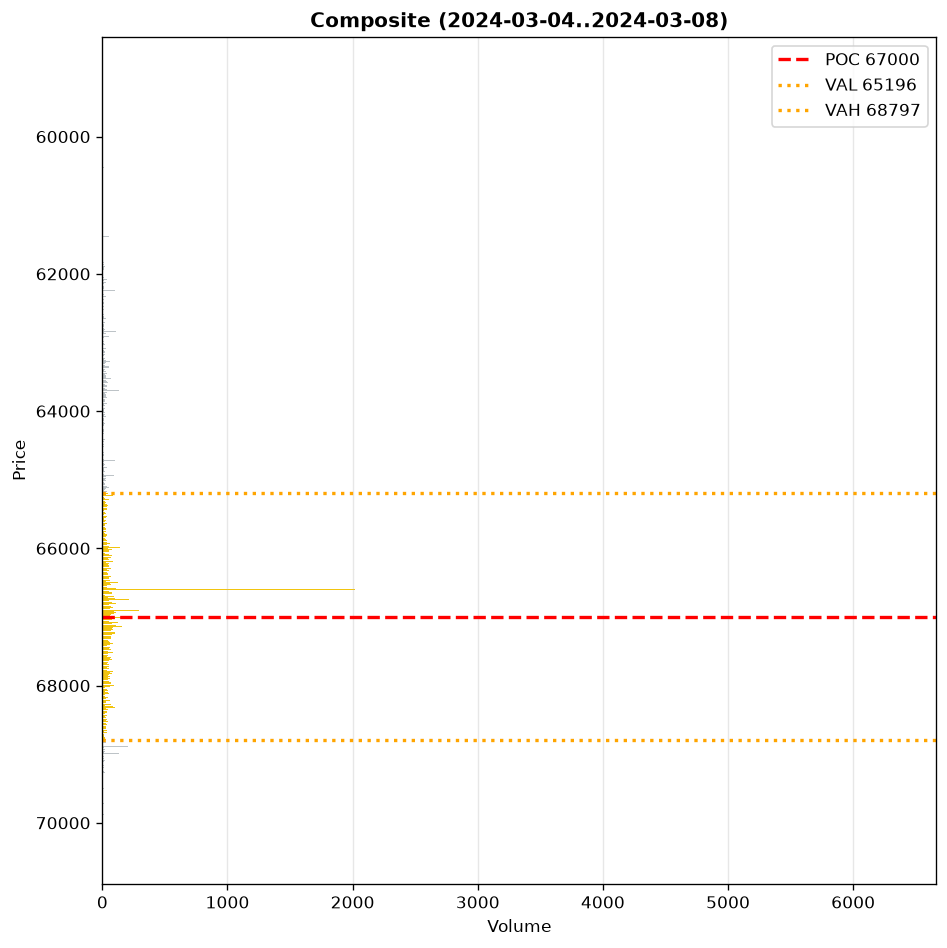

  2024-03-04: VAL=64584 POC=65000 VAH=67800
  2024-03-05: VAL=61610 POC=63300 VAH=67300
  2024-03-06: VAL=65856 POC=66000 VAH=67416
  2024-03-07: VAL=66675 POC=67000 VAH=67866
  2024-03-08: VAL=67098 POC=68000 VAH=68959


In [7]:
# === Composite Profile ===
t0=time.time()
comp_vp={}; comp_tv=0; day_profs={}
for d in PROFILE_DAYS:
    print(f'Profile {d}...',end=' ')
    df=rd_agg(d); p=calc_profile(df)
    day_profs[d]=p; comp_tv+=p.total_volume
    for px,v in p.price_levels.items(): comp_vp[px]=comp_vp.get(px,0)+v
    print(f'{len(df):,}t VAL={p.val:.0f} POC={p.poc:.0f} VAH={p.vah:.0f}'); del df

COMP=compute_vp(comp_vp,comp_tv)
print(f'Composite: VAL={COMP.val:.0f} POC={COMP.poc:.0f} VAH={COMP.vah:.0f} ({time.time()-t0:.0f}s)')

fig,ax=plt.subplots(figsize=(8,8))
sp=sorted(comp_vp.keys()); vl=[comp_vp[px] for px in sp]
cl=['#e74c3c' if px==COMP.poc else '#f1c40f' if COMP.val<=px<=COMP.vah else '#bdc3c7' for px in sp]
ax.barh(sp,vl,height=0.08,color=cl,ec='none')
ax.axhline(COMP.poc,color='red',lw=2,ls='--',label=f'POC {COMP.poc:.0f}')
ax.axhline(COMP.val,color='orange',lw=2,ls=':',label=f'VAL {COMP.val:.0f}')
ax.axhline(COMP.vah,color='orange',lw=2,ls=':',label=f'VAH {COMP.vah:.0f}')
ax.invert_yaxis(); ax.legend(); ax.set_xlabel('Volume'); ax.set_ylabel('Price')
ax.set_title(f'Composite ({PROFILE_DAYS[0]}..{PROFILE_DAYS[-1]})',fontweight='bold'); ax.grid(alpha=0.3,axis='x')
plt.tight_layout(); plt.show()
for d in PROFILE_DAYS:
    p=day_profs[d]; print(f'  {d}: VAL={p.val:.0f} POC={p.poc:.0f} VAH={p.vah:.0f}')

In [8]:
# === Pre-process all test days into 5M bars ===
t0=time.time()
first_prior_agg_prof = calc_profile(rd_agg('2024-03-10'))
print(f'Pre-cached 2024-03-10 aggTrades profile for day 1 fallback: VAL={first_prior_agg_prof.val:.0f} POC={first_prior_agg_prof.poc:.0f} VAH={first_prior_agg_prof.vah:.0f}')

ALL_BARS={}
test_day_profiles={}
prev_agg_cache={}
prev_agg_cache['2024-03-10']=first_prior_agg_prof

for i, d in enumerate(TEST_DAYS):
    print(f'\n=== {d} ===')
    td=rd_agg(d); bd=rd_bk(d)
    print(f'  aggTrades: {len(td):,} | bookTicker: {len(bd):,}')
    
    prof=calc_profile(td)
    test_day_profiles[d]=prof
    print(f'  Daily profile: VAL={prof.val:.0f} POC={prof.poc:.0f} VAH={prof.vah:.0f}')
    
    bars=build_bars(td, bd)
    ALL_BARS[d]=bars
    print(f'  Built {len(bars)} 5M bars')
    
    prev_agg_cache[d]=prof  # Store DayProfile, not full DataFrame
    del td, bd

# Clear download cache after bar building
cache_size=sum(f.stat().st_size for f in CACHE_DIR.glob('*.zip'))
shutil.rmtree(str(CACHE_DIR))
print(f'\nCache cleared ({cache_size/1024/1024:.1f}MB)')

print(f'\nPre-processing complete: {time.time()-t0:.0f}s')

Pre-cached 2024-03-10 aggTrades profile for day 1 fallback: VAL=69056 POC=69500 VAH=69976

=== 2024-03-11 ===
  aggTrades: 2,652,903 | bookTicker: 431,700
  Daily profile: VAL=70789 POC=72000 VAH=72880
  Built 288 5M bars

=== 2024-03-12 ===
  aggTrades: 2,677,909 | bookTicker: 429,955
  Daily profile: VAL=70832 POC=72000 VAH=72421
  Built 288 5M bars

=== 2024-03-13 ===
  aggTrades: 1,728,243 | bookTicker: 378,358
  Daily profile: VAL=72510 POC=73000 VAH=73560
  Built 288 5M bars

=== 2024-03-14 ===
  aggTrades: 2,861,170 | bookTicker: 492,949
  Daily profile: VAL=69000 POC=70000 VAH=72398
  Built 288 5M bars

=== 2024-03-15 ===
  aggTrades: 4,265,593 | bookTicker: 533,033
  Daily profile: VAL=67049 POC=68000 VAH=69055
  Built 288 5M bars

=== 2024-03-16 ===
  aggTrades: 2,088,215 | bookTicker: 382,875
  Daily profile: VAL=65400 POC=67200 VAH=68633
  Built 288 5M bars

=== 2024-03-17 ===
  aggTrades: 1,948,558 | bookTicker: 336,574
  Daily profile: VAL=64951 POC=65400 VAH=67411
  Buil

In [9]:
# === Execute All Experiments ===
COMP_SCORER=CompositeBiasScorer(COMP.val,COMP.poc,COMP.vah)
ALL_RESULTS={}
t0=time.time()

for exp in EXPERIMENTS:
    eid=exp['id']
    print(f'\n{"="*70}')
    print(f'  EXPERIMENT V14_{eid}: {exp["desc"]}')
    print(f'  Active: {exp.get("active_setups",["VAL_REJECTION_LONG"])} Filter={exp["filter_set"]}')
    print(f'{"="*70}')
    
    all_strats=[]
    for i, d in enumerate(TEST_DAYS):
        if i==0:
            prior=day_profs['2024-03-08']
            prior_date='2024-03-08'
            prev_agg=first_prior_agg_prof
        else:
            prior=test_day_profiles[TEST_DAYS[i-1]]
            prior_date=TEST_DAYS[i-1]
            prev_agg=prev_agg_cache.get(TEST_DAYS[i-1])
        
        strat=StrategyV14(prior.val, prior.vah, prior.poc, prior_date, prev_agg,
                          current_date=d, exp_config=exp, comp_scorer=COMP_SCORER)
        
        for candle in ALL_BARS[d]:
            strat.process_bar(candle)
        
        strat.force_close(ALL_BARS[d][-1].close if ALL_BARS[d] else 0, ALL_BARS[d][-1] if ALL_BARS[d] else None)
        all_strats.append(strat)
    
    ALL_RESULTS[eid]={
        'strats':all_strats,
        'config':exp
    }
    print(f'  Experiment done: {sum(len(s.diag.trade_log) for s in all_strats)} total legs')

print(f'\nAll experiments complete: {time.time()-t0:.0f}s')


  EXPERIMENT V14_A: v13 baseline (fixed)
  Active: ['VAL_REJECTION_LONG', 'VAH_REJECTION_SHORT'] Filter=composite_migration
>>> LONG 71049.9 stop=70393.3 sz=1.142 R=656.6 lev=0.8x (VAL_REJECTION_LONG) src=rolling_24h
  stop LONG 71211.8 (0.23% $+185) sz=1.14 lev=0.8x
>>> LONG 72585.6 stop=72186.4 sz=1.879 R=399.2 lev=1.4x (VAL_REJECTION_LONG) src=rolling_24h
  failure LONG 72332.9 (-0.35% $-473) sz=1.88 lev=1.4x
>>> LONG 69145.2 stop=68759.3 sz=1.943 R=385.9 lev=1.3x (VAL_REJECTION_LONG) src=rolling_24h
  eod LONG 69552.2 (0.59% $+796) sz=1.94 lev=1.4x
>>> SHORT 68998.3 stop=69412.3 sz=0.906 R=414.0 lev=0.6x (VAH_REJECTION_SHORT) src=rolling_24h
  target_1 SHORT 67962.6 (1.50% $+370) sz=0.36 lev=0.2x
  stop SHORT 68139.4 (1.24% $+461) sz=0.54 lev=0.4x
>>> LONG 67118.4 stop=66692.1 sz=1.759 R=426.3 lev=1.2x (VAL_REJECTION_LONG) src=rolling_24h
  stop LONG 67077.2 (-0.06% $-72) sz=1.76 lev=1.2x
>>> SHORT 67370.9 stop=67802.3 sz=1.739 R=431.4 lev=1.2x (VAH_REJECTION_SHORT) src=rolling_24

In [10]:
# === CSV Exports ===
print('Exporting CSV files...')

# 1. Trade log
all_trades=[]
for eid, res in ALL_RESULTS.items():
    for i, s in enumerate(res['strats']):
        for t in s.diag.trade_log:
            r={'exp':eid,'day':TEST_DAYS[i]}
            r.update(t)
            all_trades.append(r)
if all_trades:
    df_trades=pd.DataFrame(all_trades)
    df_trades.to_csv(OUT_DIR/'v14_trade_log.csv',index=False)
    print(f'  1. trade_log: {len(df_trades)} rows')

# 2. Daily summary
daily_rows=[]
for eid, res in ALL_RESULTS.items():
    for i, s in enumerate(res['strats']):
        legs=len(s.diag.trade_log)
        pnl=s.daily_pnl
        wins=sum(1 for t in s.diag.trade_log if t.get('pnl_usd',0)>0)
        daily_rows.append({'exp':eid,'day':TEST_DAYS[i],'legs':legs,'pnl':pnl,'wins':wins})
if daily_rows:
    df_daily=pd.DataFrame(daily_rows)
    df_daily.to_csv(OUT_DIR/'v14_daily_summary.csv',index=False)
    print(f'  2. daily_summary: {len(df_daily)} rows')

# 3. Candidate funnel
funnel_rows=[]
for eid, res in ALL_RESULTS.items():
    for sn in ['VAL_REJECTION_LONG','VAH_REJECTION_SHORT']:
        cf=defaultdict(int); ff=defaultdict(int)
        for s in res['strats']:
            for k,v in s.diag.funnel.get(sn,{}).items(): cf[k]+=v
            for k,v in s.diag.fail_funnel.get(sn,{}).items(): ff[k]+=v
        if cf:
            row={'exp':eid,'setup':sn,'total':cf.get('near_level',0)}
            for k in ['near_level','setup_enabled','profile_valid','composite_bias_ok',
                       'value_migration_ok','rejection_candle_ok','orderflow_confirmed',
                       'stop_valid','target_valid','entered']:
                row[k]=cf.get(k,0)
            top_fail=sorted(ff.items(),key=lambda x:-x[1])
            if top_fail:
                row['top_fail_stage']=top_fail[0][0]
                row['top_fail_count']=top_fail[0][1]
            funnel_rows.append(row)
if funnel_rows:
    df_funnel=pd.DataFrame(funnel_rows)
    df_funnel.to_csv(OUT_DIR/'v14_candidate_funnel.csv',index=False)
    print(f'  3. candidate_funnel: {len(df_funnel)} rows')

# 4. Dynamic profile availability
prof_avail_rows=[]
for eid, res in ALL_RESULTS.items():
    p60=defaultdict(int); p180=defaultdict(int)
    for s in res['strats']:
        for k,v in s.diag.profile_avail['60m'].items(): p60[k]+=v
        for k,v in s.diag.profile_avail['180m'].items(): p180[k]+=v
    prof_avail_rows.append({
        'exp':eid,
        '60m_eligible':p60.get('eligible',0),'60m_available':p60.get('available',0),
        '60m_pct':p60['available']/p60['eligible']*100 if p60.get('eligible',0)>0 else 0,
        '180m_eligible':p180.get('eligible',0),'180m_available':p180.get('available',0),
        '180m_pct':p180['available']/p180['eligible']*100 if p180.get('eligible',0)>0 else 0,
    })
if prof_avail_rows:
    df_prof=pd.DataFrame(prof_avail_rows)
    df_prof.to_csv(OUT_DIR/'v14_dynamic_profile_state.csv',index=False)
    print(f'  4. dynamic_profile_state: {len(df_prof)} rows')

# 5. Migration state distribution
mig_rows=[]
for eid, res in ALL_RESULTS.items():
    states=defaultdict(int)
    for s in res['strats']:
        for k,v in s.diag.migration_states.items(): states[k]+=v
    row={'exp':eid,'total':sum(states.values())}
    for st in ['STRONG_BULLISH','MODERATE_BULLISH','NEUTRAL_OVERLAP',
               'NO_CLEAR','MODERATE_BEARISH','STRONG_BEARISH']:
        row[st]=states.get(st,0)
    mig_rows.append(row)
if mig_rows:
    df_mig=pd.DataFrame(mig_rows)
    df_mig.to_csv(OUT_DIR/'v14_migration_state_distribution.csv',index=False)
    print(f'  5. migration_state_distribution: {len(df_mig)} rows')

# 6. Composite bias distribution
bias_rows=[]
for eid, res in ALL_RESULTS.items():
    states=defaultdict(int)
    for s in res['strats']:
        for k,v in s.diag.composite_bias_states.items(): states[k]+=v
    row={'exp':eid,'total':sum(states.values())}
    for st in ['BULLISH','NEUTRAL_BULLISH','NEUTRAL','NEUTRAL_BEARISH','BEARISH']:
        row[st]=states.get(st,0)
    bias_rows.append(row)
if bias_rows:
    df_bias=pd.DataFrame(bias_rows)
    df_bias.to_csv(OUT_DIR/'v14_composite_bias_distribution.csv',index=False)
    print(f'  6. composite_bias_distribution: {len(df_bias)} rows')

# 7. Setup performance by context
ctx_rows=[]
for eid, res in ALL_RESULTS.items():
    ctx=defaultdict(lambda:{'trades':0,'pnl':0.0})
    for s in res['strats']:
        for k,v in s.diag.context_pnl.items():
            ctx[k]['trades']+=v['trades']
            ctx[k]['pnl']+=v['pnl']
    for ctx_key, data in ctx.items():
        ctx_rows.append({'exp':eid,'context':ctx_key,'trades':data['trades'],'pnl':data['pnl']})
if ctx_rows:
    df_ctx=pd.DataFrame(ctx_rows)
    df_ctx.to_csv(OUT_DIR/'v14_setup_performance_by_context.csv',index=False)
    print(f'  7. setup_performance_by_context: {len(df_ctx)} rows')

# 8. MFE/MAE by setup
mfe_rows=[]
for eid, res in ALL_RESULTS.items():
    by_setup=defaultdict(list)
    for s in res['strats']:
        for t in s.diag.trade_log:
            if 'mfe' in t and 'mae' in t:
                by_setup[t.get('setup','?')].append(t)
    for setup, trades in by_setup.items():
        mfes=[t['mfe']/t.get('r_val',1) for t in trades if t.get('r_val',0)>0]
        maes=[t['mae']/t.get('r_val',1) for t in trades if t.get('r_val',0)>0]
        mfe_rows.append({
            'exp':eid,'setup':setup,'count':len(trades),
            'avg_mfe_R':np.mean(mfes) if mfes else 0,
            'avg_mae_R':np.mean(maes) if maes else 0,
            'max_mfe_R':max(mfes) if mfes else 0,
            'max_mae_R':min(maes) if maes else 0,
        })
if mfe_rows:
    df_mfe=pd.DataFrame(mfe_rows)
    df_mfe.to_csv(OUT_DIR/'v14_trade_mae_mfe_by_setup.csv',index=False)
    print(f'  8. trade_mae_mfe_by_setup: {len(df_mfe)} rows')

# 9. Rejection candle sensitivity (derived from funnel)
rej_rows=[]
for eid, res in ALL_RESULTS.items():
    for sn in ['VAL_REJECTION_LONG','VAH_REJECTION_SHORT']:
        total=0; rejected=0; passed=0
        for s in res['strats']:
            total+=s.diag.funnel.get(sn,{}).get('near_level',0)
            rejected+=s.diag.fail_funnel.get(sn,{}).get('rejection_candle_invalid',0)
            passed+=s.diag.funnel.get(sn,{}).get('rejection_candle_ok',0)
        if total>0:
            rej_rows.append({
                'exp':eid,'setup':sn,'total':total,
                'rejected':rejected,'passed':passed,
                'pass_rate':passed/total*100 if total>0 else 0
            })
if rej_rows:
    df_rej=pd.DataFrame(rej_rows)
    df_rej.to_csv(OUT_DIR/'v14_rejection_candle_sensitivity.csv',index=False)
    print(f'  9. rejection_candle_sensitivity: {len(df_rej)} rows')

# 10. VAH reclaim diagnostic
vah_rows=[]
for eid, res in ALL_RESULTS.items():
    for diag_list in [s.diag.vah_reclaim_diag for s in res['strats']]:
        for d in diag_list:
            r={'exp':eid}; r.update(d)
            vah_rows.append(r)
if vah_rows:
    df_vah=pd.DataFrame(vah_rows)
    df_vah.to_csv(OUT_DIR/'v14_vah_reclaim_diagnostic.csv',index=False)
    print(f'  10. vah_reclaim_diagnostic: {len(df_vah)} rows')

# 11. VAH_SHORT candidates
vah_short_rows=[]
for eid, res in ALL_RESULTS.items():
    for i, s in enumerate(res['strats']):
        for c in s.diag.vah_short_candidates:
            c['exp']=eid; c['day']=TEST_DAYS[i]
            vah_short_rows.append(c)
if vah_short_rows:
    df_vah_short=pd.DataFrame(vah_short_rows)
    df_vah_short.to_csv(OUT_DIR/'v14_vah_short_candidates.csv',index=False)
    print(f'  11. vah_short_candidates: {len(df_vah_short)} rows')

print(f'\nAll CSVs exported to {OUT_DIR}')

Exporting CSV files...
  1. trade_log: 146 rows
  2. daily_summary: 252 rows
  3. candidate_funnel: 18 rows
  4. dynamic_profile_state: 14 rows
  5. migration_state_distribution: 14 rows
  6. composite_bias_distribution: 14 rows
  7. setup_performance_by_context: 36 rows
  8. trade_mae_mfe_by_setup: 18 rows
  9. rejection_candle_sensitivity: 18 rows
  10. vah_reclaim_diagnostic: 67384 rows

All CSVs exported to outputs\v14


In [11]:
# === Results Comparison ===
print(f'\n{"="*75}')
print(f'  EXPERIMENT COMPARISON')
print(f'{"="*75}')
print(f'{"Exp":6s} {"Desc":28s} {"Legs":5s} {"PnL%":8s} {"PnL$":10s} {"Win%":6s} {"AvgLv":6s}')
print(f'{"-"*6} {"-"*28} {"-"*5} {"-"*8} {"-"*10} {"-"*6} {"-"*6}')

rows=[]
for eid, res in ALL_RESULTS.items():
    config=res['config']
    strats=res['strats']
    all_tr=[]
    for strat in strats:
        for t in strat.diag.trade_log: all_tr.append(t)
    
    if all_tr:
        df=pd.DataFrame(all_tr)
        total_usd=df['pnl_usd'].sum()
        wins=df[df['pnl_usd']>0]
        wr=len(wins)/len(df)*100 if len(df)>0 else 0
        avg_lev=df['leverage'].mean() if 'leverage' in df.columns else 0
        pnl_pct=total_usd/ACCOUNT_BALANCE*100
        print(f'{eid:<6s} {config["desc"]:<28s} {len(df):<5d} {pnl_pct:>+7.2f}% {total_usd:>+9.0f} {wr:>5.0f}% {avg_lev:>5.2f}x')
        rows.append({'exp':f'V14_{eid}','desc':config['desc'],'legs':len(df),'pnl_pct':pnl_pct,'pnl_usd':total_usd,'wr':wr,'avg_lev':avg_lev})
    else:
        print(f'{eid:<6s} {config["desc"]:<28s} {"0":>5s} {"0.00%":>8s} {"$0":>10s} {"0%":>6s} {"0x":>6s}')


  EXPERIMENT COMPARISON
Exp    Desc                         Legs  PnL%     PnL$       Win%   AvgLv 
------ ---------------------------- ----- -------- ---------- ------ ------
A      v13 baseline (fixed)         14      +3.49%     +3492    50%  0.89x
A0     Fixed migration + 5M bars    14      +3.49%     +3492    50%  0.89x
A1     VAL_REJECTION only           9       +3.49%     +3490    56%  0.98x
B1     VAH_SHORT only strict        14      +3.52%     +3523    50%  0.89x
C1     VAL + strict VAH             14      +3.49%     +3492    50%  0.89x
D1     No composite/migration       9       +3.49%     +3490    56%  0.98x
D2     Composite only               9       +3.49%     +3490    56%  0.98x
D3     Migration only               9       +3.49%     +3490    56%  0.98x
D4     Composite + migration        9       +3.49%     +3490    56%  0.98x
D5     Strict composite+migration   9       +3.49%     +3490    56%  0.98x
E1     Close loc >= 0.50            9       +3.32%     +3324    56%  0.98

In [12]:
# === Funnel Diagnostics ===
baseline=ALL_RESULTS.get('A')
if baseline:
    stages=['near_level','setup_enabled','profile_valid','composite_bias_ok','value_migration_ok',
            'rejection_candle_ok','orderflow_confirmed','stop_valid','target_valid','entered']
    for sn in ['VAL_REJECTION_LONG','VAH_REJECTION_SHORT']:
        cf=defaultdict(int); ff=defaultdict(int)
        for s in baseline['strats']:
            for k,v in s.diag.funnel.get(sn,{}).items(): cf[k]+=v
            for k,v in s.diag.fail_funnel.get(sn,{}).items(): ff[k]+=v
        total=cf.get('near_level',0)
        if total==0: continue
        print(f'\n  {sn}: {total} candidates')
        for st in stages:
            cnt=cf.get(st,0)
            print(f'    {" >>>" if st=="entered" else "    "} {cnt:6d}/{total} ({cnt/total*100:5.1f}%)  {st}')
        fail_items=sorted([(k,v) for k,v in ff.items()],key=lambda x:-x[1])[:5]
        if fail_items:
            print(f'    Top fails:')
            for k,v in fail_items:
                print(f'      {v:6d} ({v/total*100:5.1f}%)  {k}')


  VAL_REJECTION_LONG: 4769 candidates
           4769/4769 (100.0%)  near_level
           3961/4769 ( 83.1%)  setup_enabled
           3961/4769 ( 83.1%)  profile_valid
           2973/4769 ( 62.3%)  composite_bias_ok
           2971/4769 ( 62.3%)  value_migration_ok
             28/4769 (  0.6%)  rejection_candle_ok
             17/4769 (  0.4%)  orderflow_confirmed
              7/4769 (  0.1%)  stop_valid
              7/4769 (  0.1%)  target_valid
     >>>      7/4769 (  0.1%)  entered
    Top fails:
        2943 ( 61.7%)  rejection_candle_invalid
         988 ( 20.7%)  composite_bias_rejected
         808 ( 16.9%)  setup_disabled
          11 (  0.2%)  orderflow_not_confirmed
          10 (  0.2%)  stop_too_wide

  VAH_REJECTION_SHORT: 4769 candidates
           4769/4769 (100.0%)  near_level
           4061/4769 ( 85.2%)  setup_enabled
           4061/4769 ( 85.2%)  profile_valid
           3192/4769 ( 66.9%)  composite_bias_ok
           3190/4769 ( 66.9%)  value_migration_ok


In [13]:
# === Profile Availability + Migration Diagnostics ===
for eid, res in ALL_RESULTS.items():
    p60_eligible=sum(s.diag.profile_avail['60m']['eligible'] for s in res['strats'])
    p60_avail=sum(s.diag.profile_avail['60m']['available'] for s in res['strats'])
    p180_eligible=sum(s.diag.profile_avail['180m']['eligible'] for s in res['strats'])
    p180_avail=sum(s.diag.profile_avail['180m']['available'] for s in res['strats'])
    print(f'\nV14_{eid}: Profile availability')
    print(f'  60M: {p60_avail}/{p60_eligible} ({p60_avail/p60_eligible*100:.1f}%)')
    print(f'  180M: {p180_avail}/{p180_eligible} ({p180_avail/p180_eligible*100:.1f}%)')
    
    states=defaultdict(int)
    for s in res['strats']:
        for k,v in s.diag.migration_states.items(): states[k]+=v
    if states:
        total=sum(states.values())
        print(f'  Migration states ({total}):')
        for st in ['STRONG_BULLISH','MODERATE_BULLISH','NEUTRAL_OVERLAP',
                    'NO_CLEAR','MODERATE_BEARISH','STRONG_BEARISH']:
            cnt=states.get(st,0)
            if cnt>0: print(f'    {st}: {cnt} ({cnt/total*100:.1f}%)')


V14_A: Profile availability
  60M: 3972/3972 (100.0%)
  180M: 1927/1927 (100.0%)
  Migration states (4769):
    STRONG_BULLISH: 8 (0.2%)
    MODERATE_BULLISH: 1264 (26.5%)
    NEUTRAL_OVERLAP: 34 (0.7%)
    NO_CLEAR: 2544 (53.3%)
    MODERATE_BEARISH: 901 (18.9%)
    STRONG_BEARISH: 18 (0.4%)

V14_A0: Profile availability
  60M: 3972/3972 (100.0%)
  180M: 1927/1927 (100.0%)
  Migration states (4769):
    STRONG_BULLISH: 8 (0.2%)
    MODERATE_BULLISH: 1264 (26.5%)
    NEUTRAL_OVERLAP: 34 (0.7%)
    NO_CLEAR: 2544 (53.3%)
    MODERATE_BEARISH: 901 (18.9%)
    STRONG_BEARISH: 18 (0.4%)

V14_A1: Profile availability
  60M: 4031/4031 (100.0%)
  180M: 1927/1927 (100.0%)
  Migration states (4831):
    STRONG_BULLISH: 7 (0.1%)
    MODERATE_BULLISH: 1300 (26.9%)
    NEUTRAL_OVERLAP: 35 (0.7%)
    NO_CLEAR: 2570 (53.2%)
    MODERATE_BEARISH: 901 (18.7%)
    STRONG_BEARISH: 18 (0.4%)

V14_B1: Profile availability
  60M: 3972/3972 (100.0%)
  180M: 1927/1927 (100.0%)
  Migration states (4769):
   

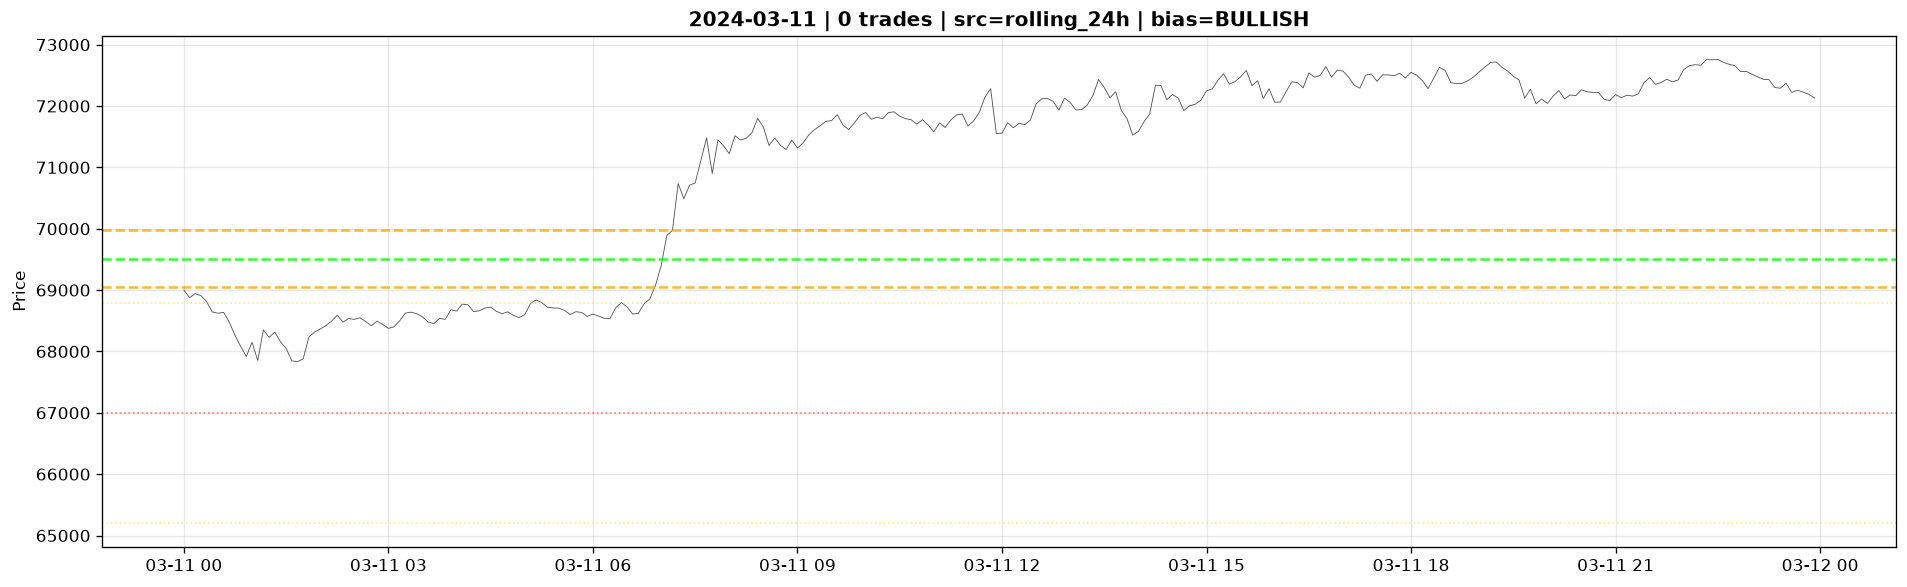

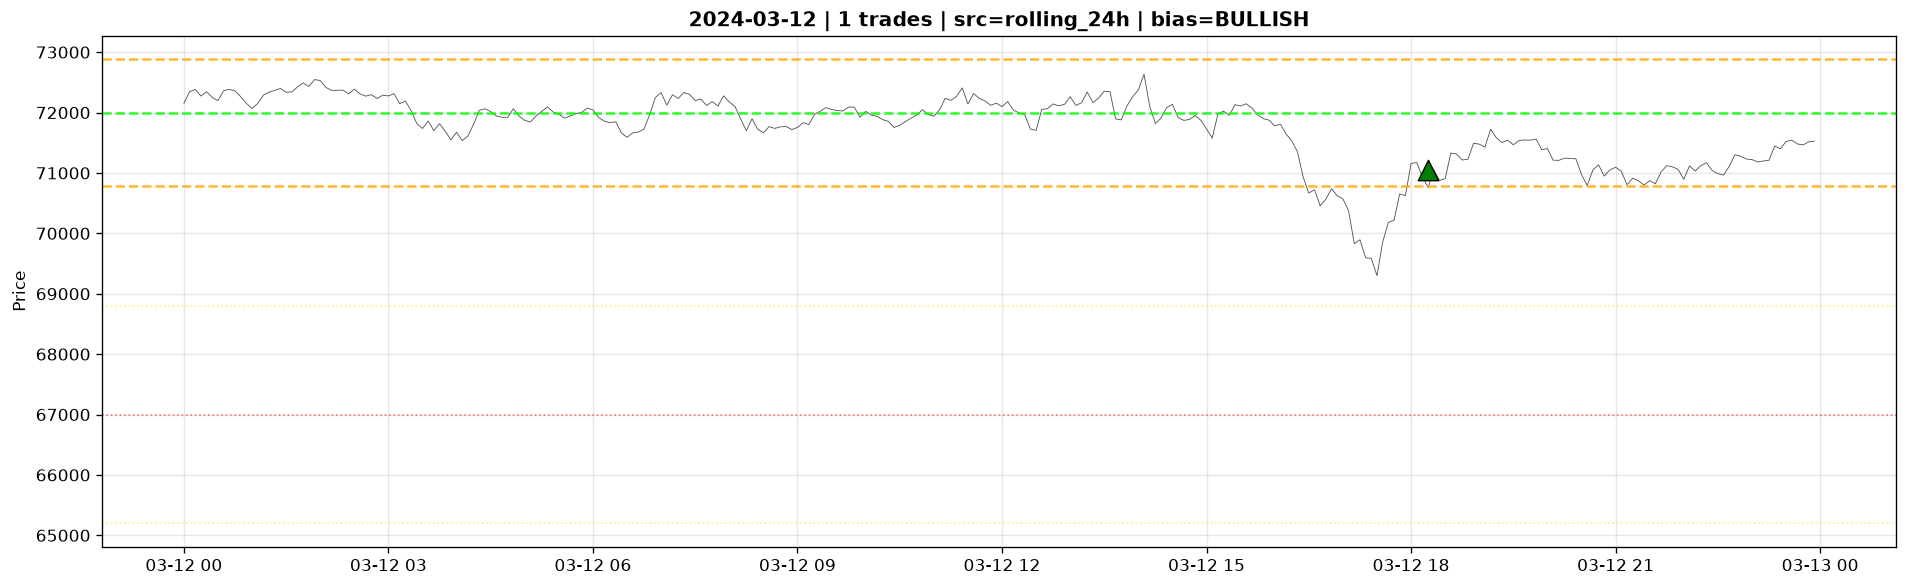

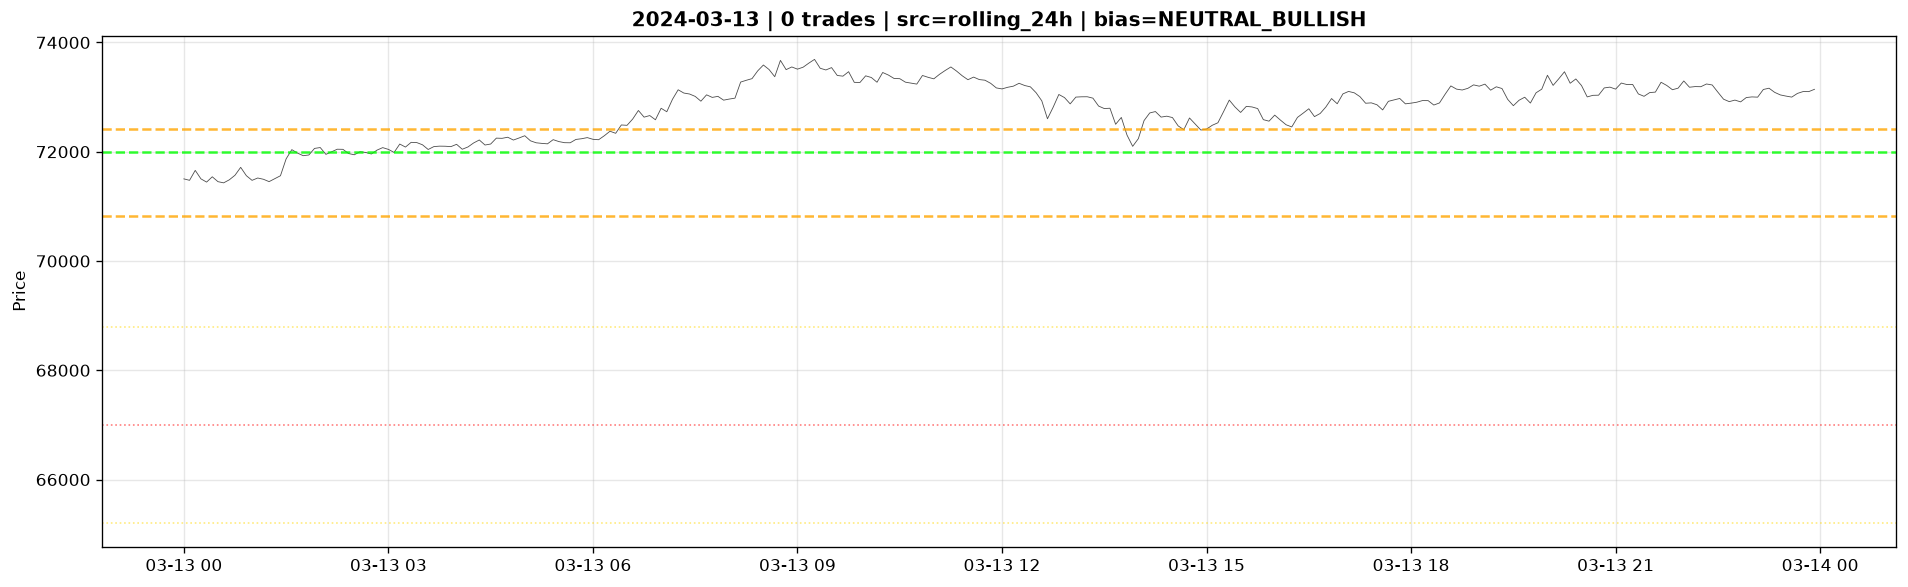

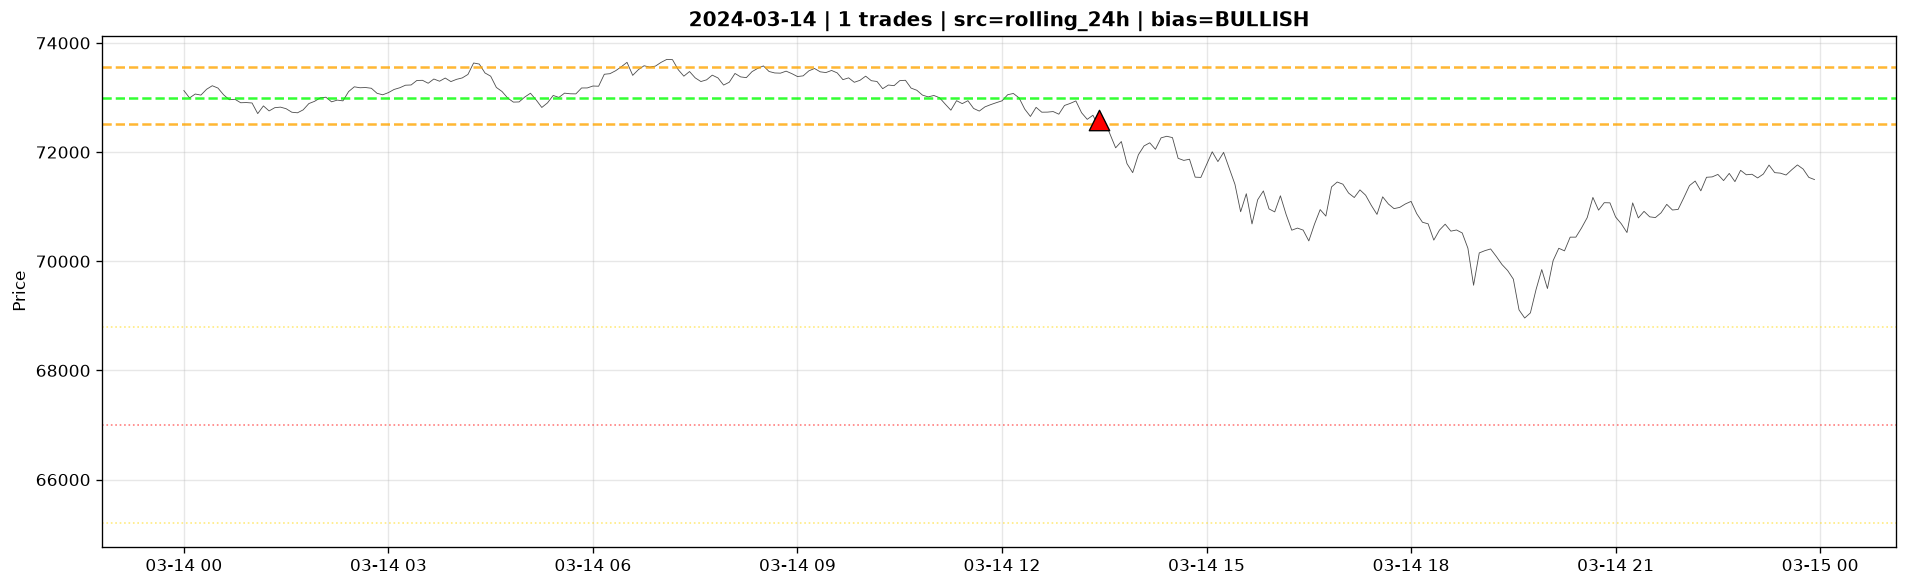

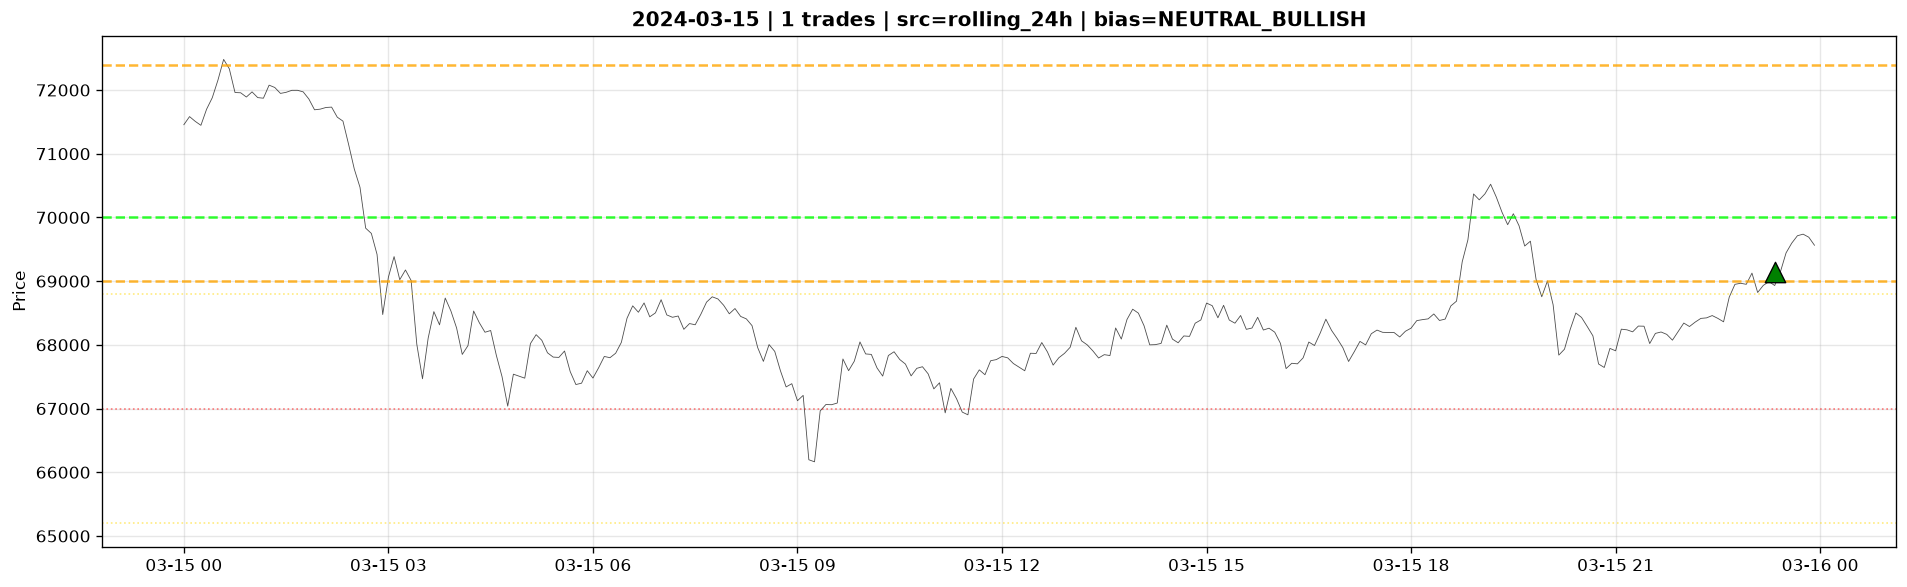

In [14]:
# === Charts - Baseline First 5 Days ===
baseline=ALL_RESULTS.get('A')
if baseline:
    for i, d in enumerate(TEST_DAYS[:5]):
        strat=baseline['strats'][i]
        bars=ALL_BARS[d]
        if not bars: continue
        
        fig,ax=plt.subplots(figsize=(16,5))
        times=[pd.Timestamp(b.ts_start,unit='ms') for b in bars]
        prices=[b.open_p for b in bars]
        ax.plot(times,prices,'k-',lw=0.5,alpha=0.7)
        
        for label,px,color in [
            (f'Comp VAL {COMP.val:.0f}',COMP.val,'gold'),
            (f'Comp POC {COMP.poc:.0f}',COMP.poc,'red'),
            (f'Comp VAH {COMP.vah:.0f}',COMP.vah,'gold'),
        ]:
            ax.axhline(px,color=color,lw=1,ls=':',alpha=0.5)
        
        for label,px,color in [
            (f'Active VAL {strat.active_VAL:.0f}',strat.active_VAL,'orange'),
            (f'Active POC {strat.active_POC:.0f}',strat.active_POC,'lime'),
            (f'Active VAH {strat.active_VAH:.0f}',strat.active_VAH,'orange'),
        ]:
            ax.axhline(px,color=color,lw=1.5,ls='--',alpha=0.8)
        
        for t in strat.diag.trade_log:
            col='green' if t.get('pnl_usd',0)>0 else 'red'
            mk='^' if t['side']=='LONG' else 'v'
            ax.scatter(pd.Timestamp(t.get('entry_ts',0),unit='ms'),t['entry'],
                      marker=mk,color=col,s=150,zorder=5,edgecolors='black',linewidth=0.8)
        
        ax.set_title(f'{d} | {len(strat.diag.trade_log)} trades | src={strat.active_source} | bias={strat.composite_bias_state}',
                     fontweight='bold')
        ax.set_ylabel('Price'); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

---
## v14 Changes Summary

- **5M bars**: switched from 1M to 5M bars
- **CandleBuffer fixed**: `get_60m_profile()` now computes on first call instead of returning None
- **Migration order fixed**: `update_prev()` called after `migration_state()`
- **5-state migration**: STRONG_BULLISH, MODERATE_BULLISH, NEUTRAL_OVERLAP, MODERATE_BEARISH, STRONG_BEARISH
- **VAL_REJECTION_LONG**: active setup with close_location >= 0.55, red candle filtering, context-based blocking
- **VAH_REJECTION_SHORT**: diagnostics-first; only trades if explicitly in active_setups
- **VAH_RECLAIM_LONG**: diagnostics-only
- **Stops tuned**: min/max distances updated per plan
- **T2 conditions**: require 2-bar POC confirmation + CVD alignment
- **RAM**: disk-based download cache, DayProfile prev_agg_cache
- **MFE/MAE**: per-trade tracking
- **15 experiments**: A, A0, A1, B1, C1, D1-D5, E1-E3, F1
- **11 CSV exports**: full diagnostic pipeline
